# Exploratory Data Analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Loading the  dataset
df = pd.read_csv("full_data_unhealthy_imputed_reduced.csv")

print("Shape of dataset:", df.shape)
print("\nInfo:")
print(df.info())
print("\nFirst rows:")
print(df.head())

Shape of dataset: (318166, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318166 entries, 0 to 318165
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   cow             318166 non-null  int64  
 1   date            318166 non-null  object 
 2   hour_bin        318166 non-null  int64  
 3   IN_ALLEYS       318166 non-null  float64
 4   REST            318166 non-null  float64
 5   EAT             318166 non-null  float64
 6   ACTIVITY_LEVEL  318166 non-null  float64
 7   oestrus         318166 non-null  int64  
 8   calving         318166 non-null  int64  
 9   lameness        318166 non-null  int64  
 10  mastitis        318166 non-null  int64  
 11  disturbance     318166 non-null  int64  
dtypes: float64(4), int64(7), object(1)
memory usage: 29.1+ MB
None

First rows:
   cow        date  hour_bin   IN_ALLEYS         REST          EAT  \
0  156  2015-03-02         0  261.545143  2635.472143   

In [8]:
# Missing values & Duplicates
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
cow               0
date              0
hour_bin          0
IN_ALLEYS         0
REST              0
EAT               0
ACTIVITY_LEVEL    0
oestrus           0
calving           0
lameness          0
mastitis          0
disturbance       0
dtype: int64

Duplicate rows: 0


In [9]:
# Summary statistics
print("Summary statistics:")
print(df.describe())

Summary statistics:
                 cow       hour_bin      IN_ALLEYS           REST  \
count  318166.000000  318166.000000  318166.000000  318166.000000   
mean    69268.834731      11.829800     632.193013    2137.787259   
std     22351.195584       8.891731     494.436839     841.364885   
min       156.000000       0.000000       0.000000       0.000000   
25%     53860.000000       0.000000     333.289719    1637.748964   
50%     74650.000000       8.000000     535.713116    2125.385946   
75%     85795.000000      16.000000     800.814964    2714.353857   
max     98350.000000      24.000000    3599.999000    3599.999000   

                 EAT  ACTIVITY_LEVEL        oestrus        calving  \
count  318166.000000   318166.000000  318166.000000  318166.000000   
mean      826.696095      -43.327829       0.004032       0.002225   
std       657.558796      476.838387       0.063374       0.047120   
min         0.000000     -827.999800       0.000000       0.000000   
25%     

Counts:
oestrus     1283
calving      708
lameness     532
mastitis     167
dtype: int64

Percentages:
oestrus     0.403249
calving     0.222525
lameness    0.167208
mastitis    0.052488
dtype: float64


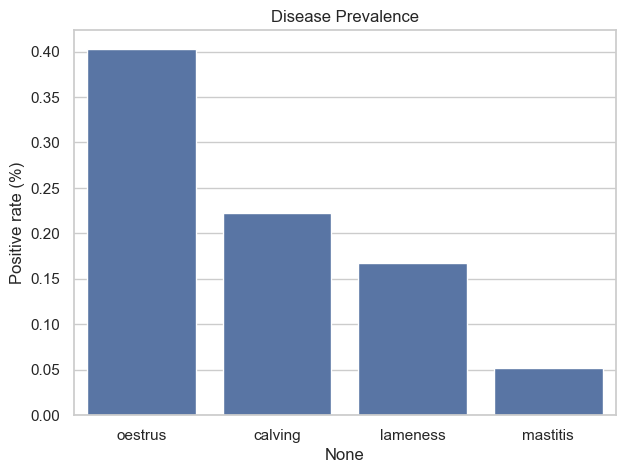

In [12]:
# Disease prevalence (counts and percentages)
disease_cols = ["oestrus", "calving", "lameness", "mastitis"]

counts = df[disease_cols].sum()
perc = (counts / len(df)) * 100

print("Counts:")
print(counts)
print("\nPercentages:")
print(perc)

plt.figure(figsize=(7,5))
sns.barplot(x=counts.index, y=perc.values)
plt.ylabel("Positive rate (%)")
plt.title("Disease Prevalence")
plt.show()

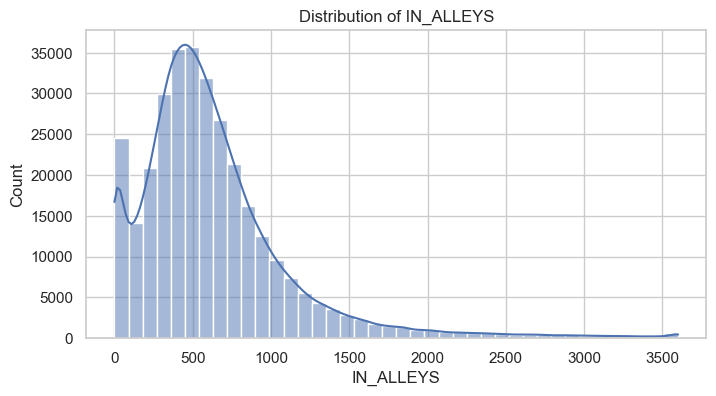

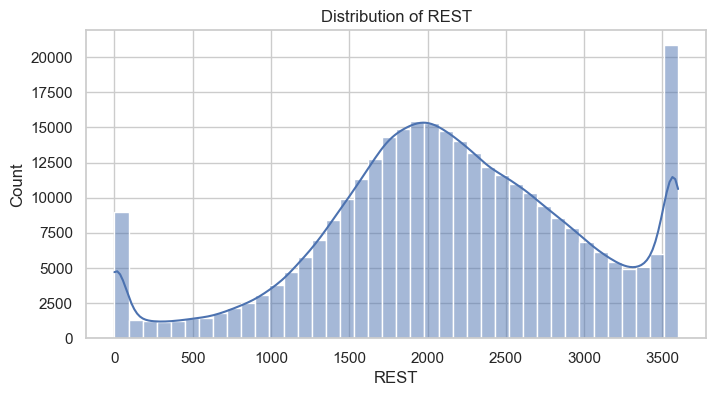

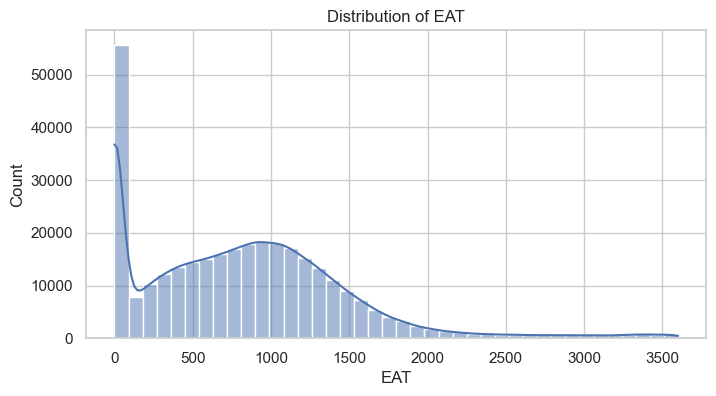

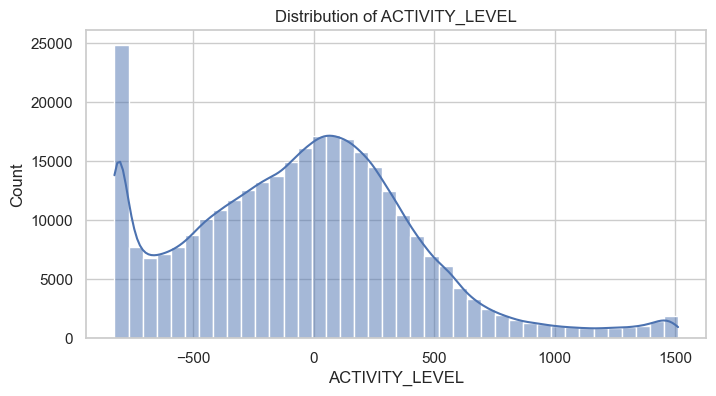

In [16]:
# Distributions for behavioural features
features = ["IN_ALLEYS", "REST", "EAT", "ACTIVITY_LEVEL"]

for col in features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.show()

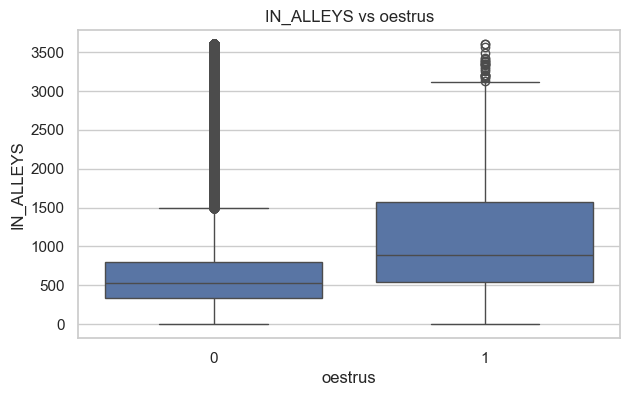

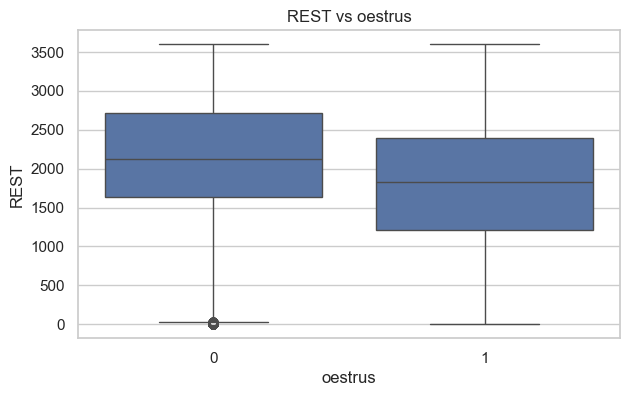

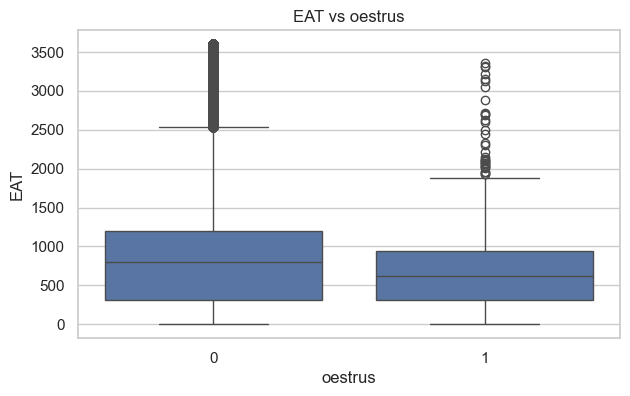

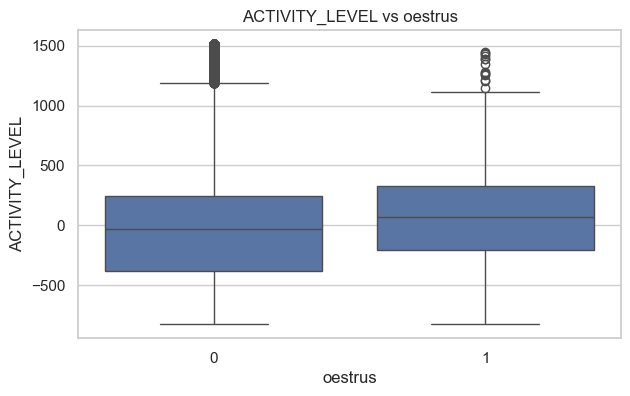

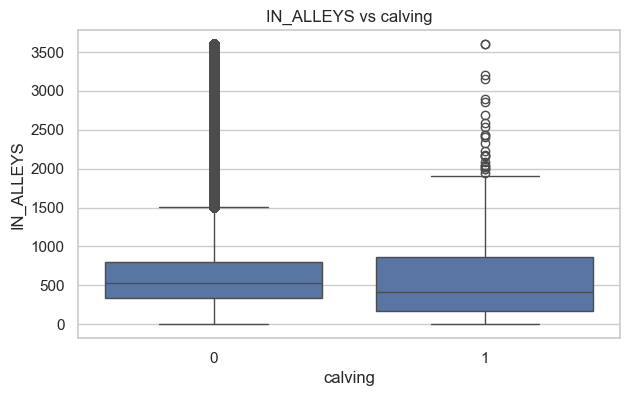

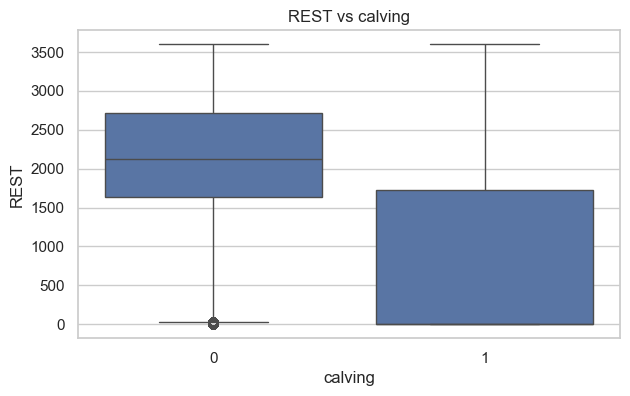

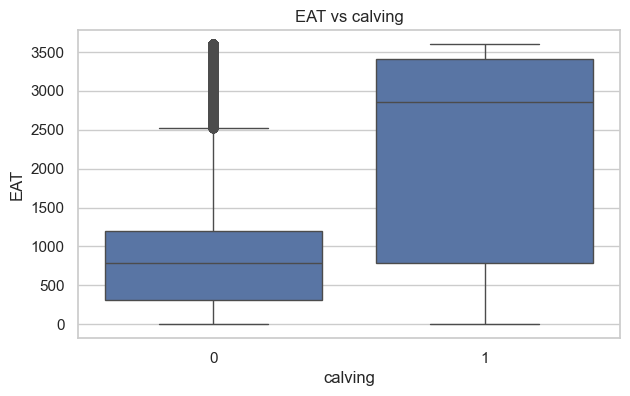

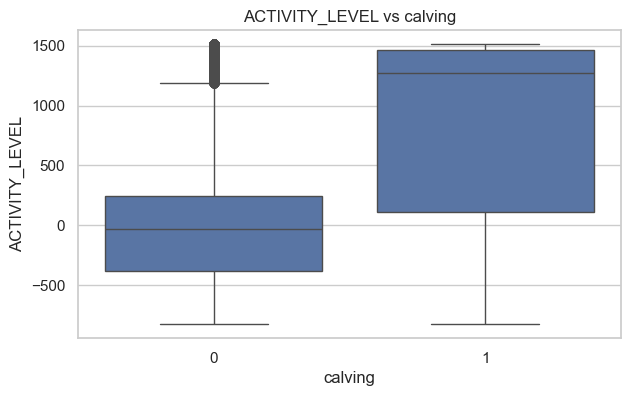

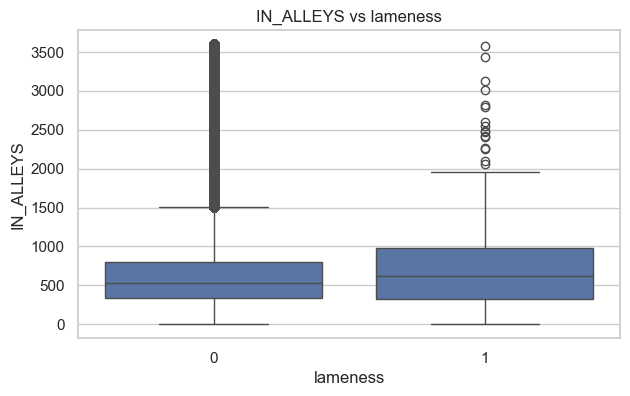

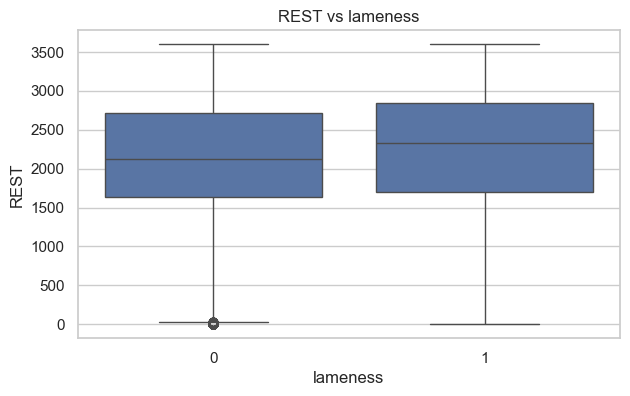

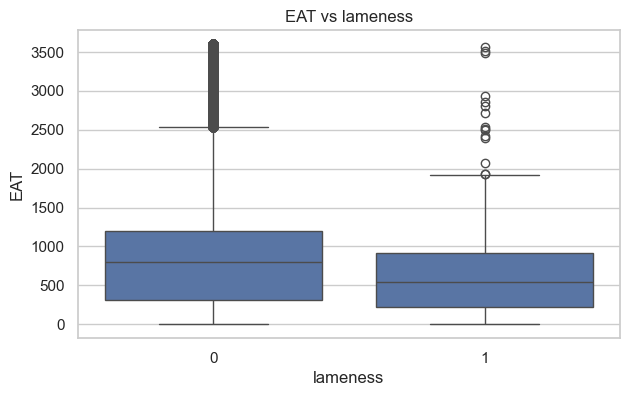

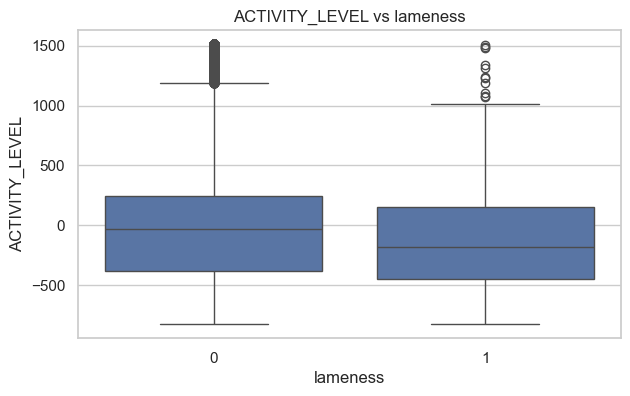

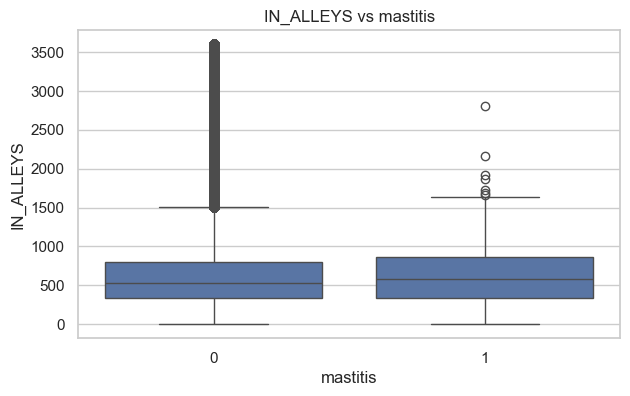

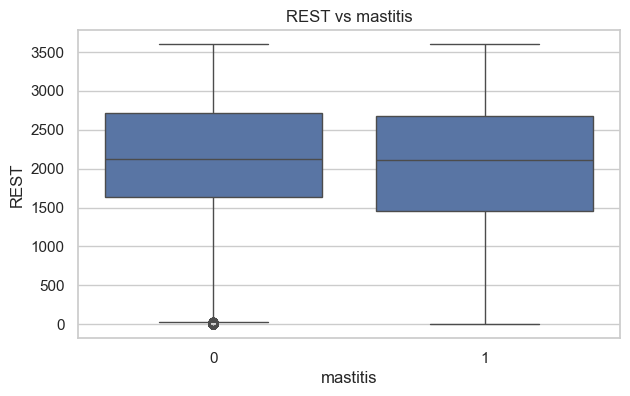

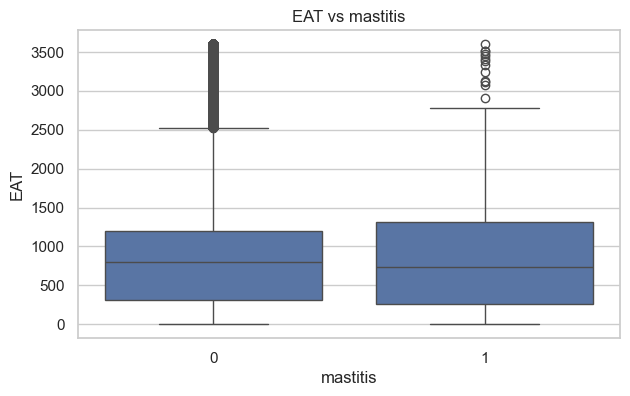

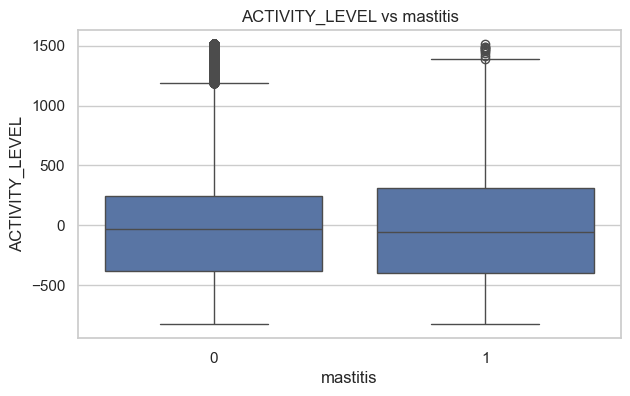

In [17]:
# Boxplots: behaviour vs disease labels
for disease in ["oestrus", "calving", "lameness", "mastitis"]:
    for feat in ["IN_ALLEYS", "REST", "EAT", "ACTIVITY_LEVEL"]:
        plt.figure(figsize=(7,4))
        sns.boxplot(x=disease, y=feat, data=df)
        plt.title(f"{feat} vs {disease}")
        plt.show()

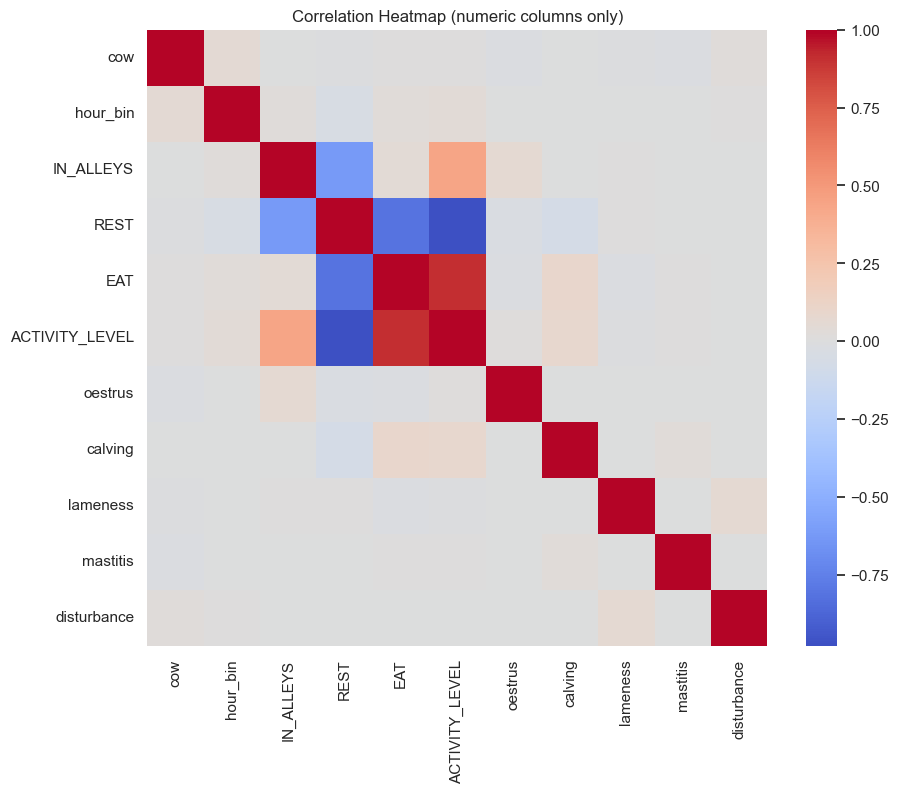

In [23]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric columns only)")
plt.show()

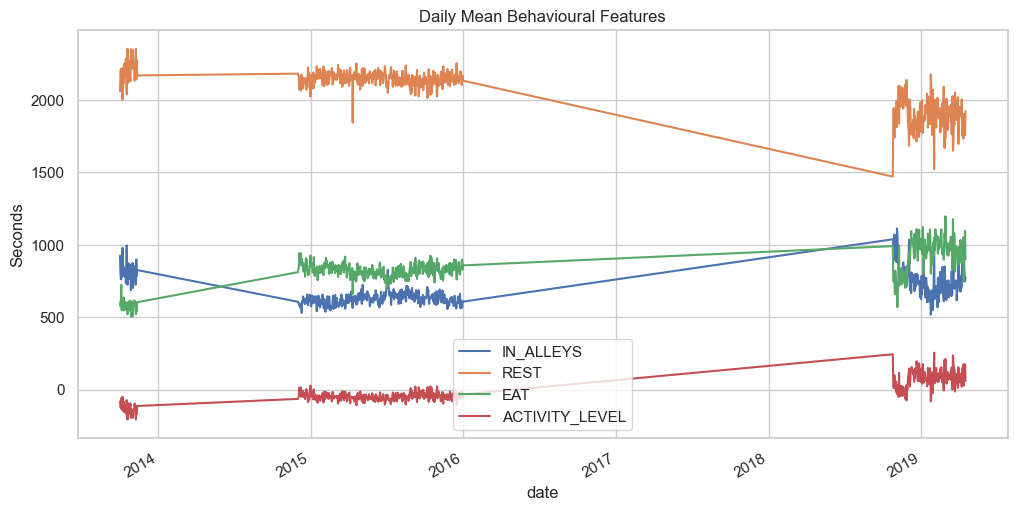

In [21]:
# Time-based exploration: daily averages
df['date'] = pd.to_datetime(df['date'])
daily_means = df.groupby('date')[["IN_ALLEYS","REST","EAT","ACTIVITY_LEVEL"]].mean()

daily_means.plot(figsize=(12,6))
plt.title("Daily Mean Behavioural Features")
plt.ylabel("Seconds")
plt.show()

In [25]:
import numpy as np

# Helper: Cohen's d
def cohens_d(x_pos, x_neg):
    m1, m2 = np.mean(x_pos), np.mean(x_neg)
    s1, s2 = np.std(x_pos, ddof=1), np.std(x_neg, ddof=1)
    n1, n2 = len(x_pos), len(x_neg)
    # pooled standard deviation
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (m1 - m2) / sp if sp > 0 else np.nan

disease_cols = ["oestrus", "calving", "lameness", "mastitis"]
features = ["IN_ALLEYS", "REST", "EAT", "ACTIVITY_LEVEL"]

effect_sizes = []
for disease in disease_cols:
    for feat in features:
        pos = df.loc[df[disease] == 1, feat]
        neg = df.loc[df[disease] == 0, feat]
        d = cohens_d(pos, neg)
        effect_sizes.append([disease, feat, d])

cohen_df = pd.DataFrame(effect_sizes, columns=["Disease", "Feature", "Cohen_d"])
display(cohen_df)


,Disease,Feature,Cohen_d
0,oestrus,IN_ALLEYS,1.000248
1,oestrus,REST,-0.401334
2,oestrus,EAT,-0.235595
3,oestrus,ACTIVITY_LEVEL,0.192011
4,calving,IN_ALLEYS,-0.069950
5,calving,REST,-1.543755
6,calving,EAT,2.031194
7,calving,ACTIVITY_LEVEL,1.790655
8,lameness,IN_ALLEYS,0.199127
9,lameness,REST,0.110442


C:\Users\vishn\AppData\Local\Temp\ipykernel_4168\1424696559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=feat, data=df, ax=axes[i,j], palette="Set2")
C:\Users\vishn\AppData\Local\Temp\ipykernel_4168\1424696559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=feat, data=df, ax=axes[i,j], palette="Set2")
C:\Users\vishn\AppData\Local\Temp\ipykernel_4168\1424696559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=disease, y=feat, data=df, ax=axes[i,j], palette="Set2")
C:\Users\vishn\AppData\Local\Temp\

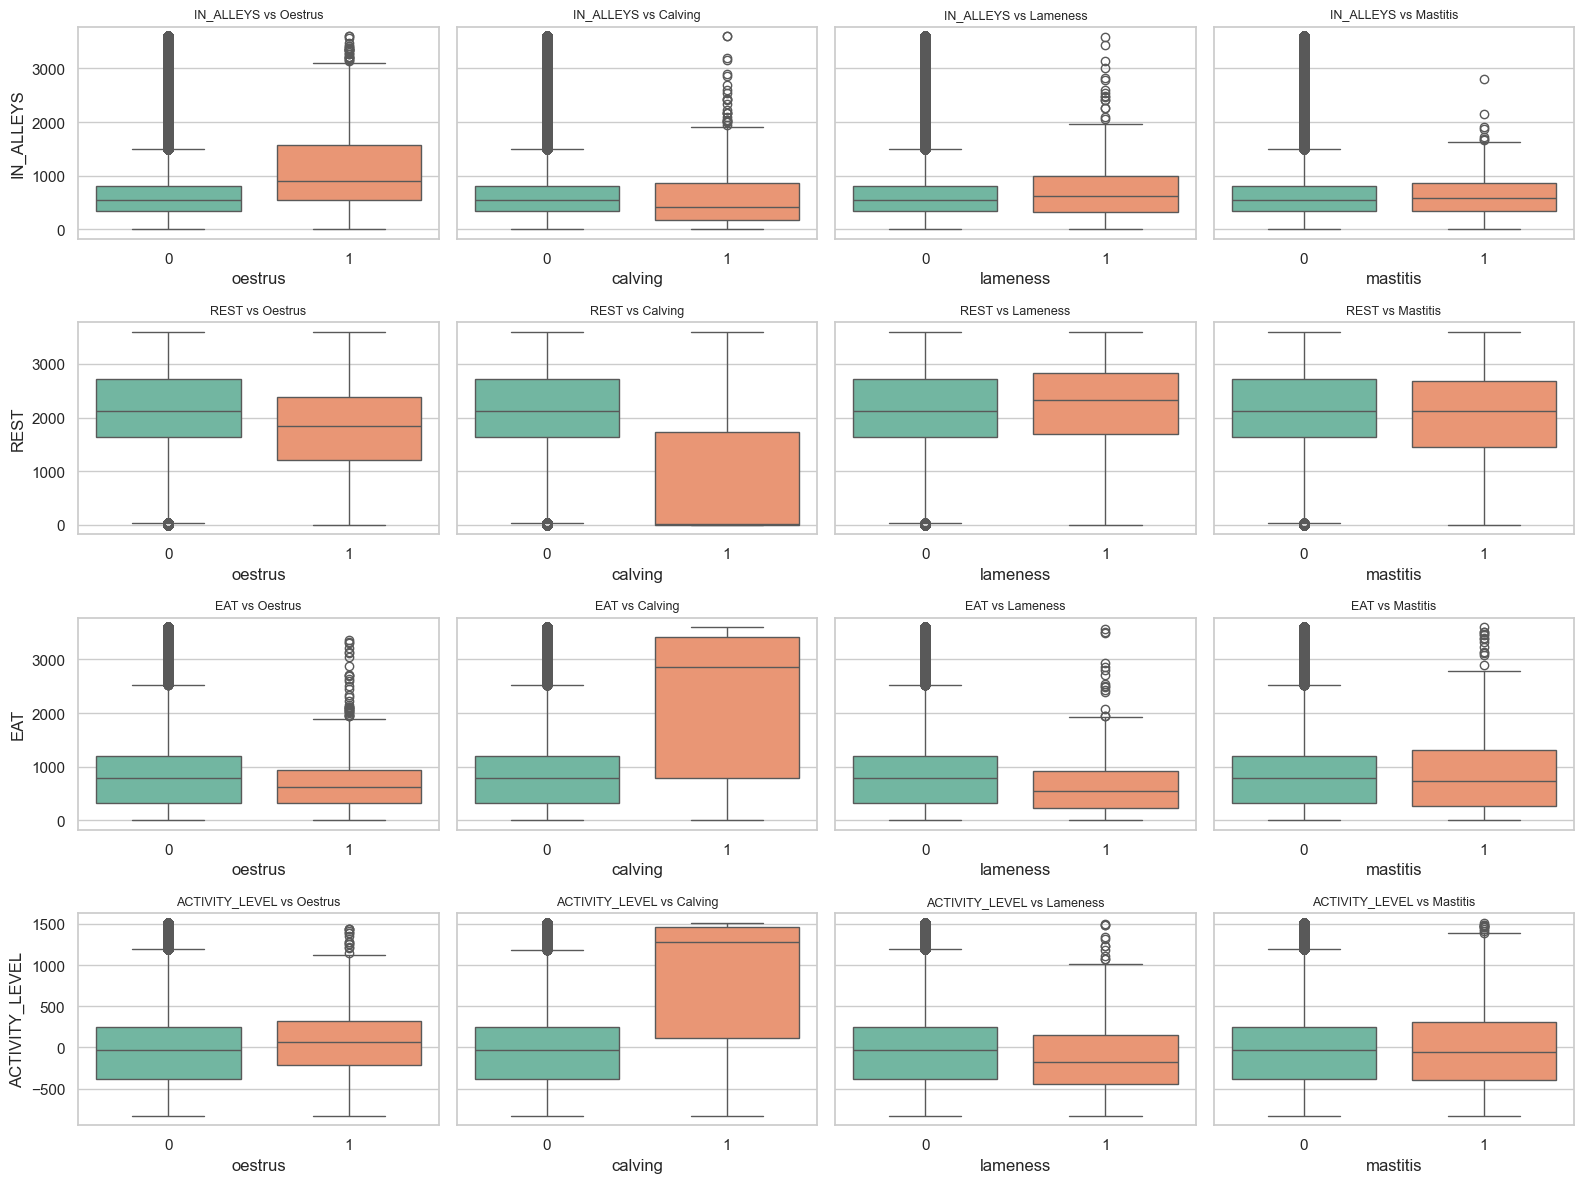

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["IN_ALLEYS", "REST", "EAT", "ACTIVITY_LEVEL"]
disease_cols = ["oestrus", "calving", "lameness", "mastitis"]

fig, axes = plt.subplots(len(features), len(disease_cols), figsize=(16,12), sharey='row')

for i, feat in enumerate(features):
    for j, disease in enumerate(disease_cols):
        sns.boxplot(x=disease, y=feat, data=df, ax=axes[i,j], palette="Set2")
        axes[i,j].set_title(f"{feat} vs {disease.capitalize()}", fontsize=9)

plt.tight_layout()
plt.show()
